# Task 5 — Multi-Asset Connectivity Analysis

## Objective
Model relationships between assets and understand:
- Asset hierarchy
- Connected and dependent assets
- Isolated assets
- Failure propagation
- Connectivity data quality

### Core flow
**Load → Hierarchy → Graph → Connectivity → Dependency → Failure Impact → Criticality → Data Quality → Visualizations → Report → Recommendations**

> Note: the supplied metadata does not contain a `floor_id`, so the hierarchy uses **Site → Building → Asset / Parent Asset**.

## 01. Load + Validate Data

Load the three datasets:
- Telemetry
- Asset metadata
- Asset connectivity

First validate IDs and relationship records before constructing the graph.

In [17]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

SEED = 42
np.random.seed(SEED)

possible_dirs = [Path("../data/raw"), Path("data/raw")]

DATA_DIR = next(
    (p for p in possible_dirs
     if (p / "asset_metadata.csv").exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/raw/asset_metadata.csv"
    )

telemetry = pd.read_csv(DATA_DIR / "sensor_telemetry.csv")
metadata = pd.read_csv(DATA_DIR / "asset_metadata.csv")
connectivity = pd.read_csv(DATA_DIR / "asset_connectivity.csv")

telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])
metadata["installation_date"] = pd.to_datetime(
    metadata["installation_date"]
)

print("Telemetry     :", telemetry.shape)
print("Metadata      :", metadata.shape)
print("Connectivity  :", connectivity.shape)

display(metadata.head())
display(connectivity.head())

Telemetry     : (259200, 12)
Metadata      : (30, 9)
Connectivity  : (36, 4)


,asset_id,site_id,building_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id
0,ASSET_001,SITE_01,BLDG_01,Chiller-01,Chiller,Carrier,2022-07-18,1000,NaN
1,ASSET_002,SITE_01,BLDG_01,AHU-01-1,AHU,Daikin,2023-06-27,200,ASSET_001
2,ASSET_003,SITE_01,BLDG_01,AHU-01-2,AHU,Trane,2022-05-23,150,ASSET_001
3,ASSET_004,SITE_01,BLDG_01,Pump-01,Pump,KSB,2024-11-05,100,ASSET_001
4,ASSET_005,SITE_01,BLDG_01,EnergyMeter-01,Energy Meter,ABB,2023-08-13,500,NaN


,source_asset_id,target_asset_id,connection_type,relationship_strength
0,ASSET_001,ASSET_002,Supplies,0.89
1,ASSET_001,ASSET_002,Controls,0.68
2,ASSET_001,ASSET_003,Supplies,0.82
3,ASSET_001,ASSET_003,Controls,0.65
4,ASSET_004,ASSET_001,Supplies,0.70


In [18]:
# Dashboard / artifact output location
# When this notebook is run from the Jupyter Notebook folder,
# ../outputs points to the project-level outputs folder.
OUTPUTS_DIR = (
    Path("../outputs")
    if Path("../outputs").exists()
    else Path("outputs")
)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# Basic validation

asset_ids = set(metadata["asset_id"])

duplicate_assets = metadata["asset_id"].duplicated().sum()

duplicate_connections = connectivity.duplicated(
    subset=[
        "source_asset_id",
        "target_asset_id",
        "connection_type"
    ]
).sum()

self_connections = (
    connectivity["source_asset_id"]
    == connectivity["target_asset_id"]
).sum()

missing_source = (
    ~connectivity["source_asset_id"].isin(asset_ids)
).sum()

missing_target = (
    ~connectivity["target_asset_id"].isin(asset_ids)
).sum()

print("Duplicate asset IDs       :", duplicate_assets)
print("Duplicate connections     :", duplicate_connections)
print("Self-connections          :", self_connections)
print("Invalid source assets     :", missing_source)
print("Invalid target assets     :", missing_target)

print("\nConnection types:")
display(connectivity["connection_type"].value_counts())

Duplicate asset IDs       : 0
Duplicate connections     : 0
Self-connections          : 0
Invalid source assets     : 0
Invalid target assets     : 0

Connection types:


connection_type
Supplies    18
Controls    12
Monitors     6
Name: count, dtype: int64

## 02. Build Asset Hierarchy

Use the metadata relationship:

`parent_asset_id`

to build the asset hierarchy.

### Structure

```text
Site
 └── Building
      └── Parent Asset
           └── Child Asset
```

This is a hierarchy view; it is kept separate from the operational connectivity graph.

In [20]:
# Validate parent_asset_id

valid_parent_ids = asset_ids

metadata["parent_exists"] = (
    metadata["parent_asset_id"].isna()
    | metadata["parent_asset_id"].isin(valid_parent_ids)
)

invalid_parents = metadata[
    ~metadata["parent_exists"]
]

self_parents = metadata[
    metadata["asset_id"] == metadata["parent_asset_id"]
]

print("Assets with valid parent mapping:",
      int(metadata["parent_exists"].sum()))
print("Invalid parent mappings:",
      len(invalid_parents))
print("Self-parent mappings:",
      len(self_parents))

# Parent-child lookup
children_by_parent = (
    metadata.dropna(subset=["parent_asset_id"])
    .groupby("parent_asset_id")["asset_id"]
    .apply(list)
    .to_dict()
)

display(
    metadata[
        [
            "site_id",
            "building_id",
            "asset_id",
            "asset_type",
            "parent_asset_id"
        ]
    ].head(15)
)

Assets with valid parent mapping: 30
Invalid parent mappings: 0
Self-parent mappings: 0


,site_id,building_id,asset_id,asset_type,parent_asset_id
0,SITE_01,BLDG_01,ASSET_001,Chiller,NaN
1,SITE_01,BLDG_01,ASSET_002,AHU,ASSET_001
2,SITE_01,BLDG_01,ASSET_003,AHU,ASSET_001
3,SITE_01,BLDG_01,ASSET_004,Pump,ASSET_001
4,SITE_01,BLDG_01,ASSET_005,Energy Meter,NaN
5,SITE_01,BLDG_02,ASSET_006,Chiller,NaN
6,SITE_01,BLDG_02,ASSET_007,AHU,ASSET_006
7,SITE_01,BLDG_02,ASSET_008,AHU,ASSET_006
8,SITE_01,BLDG_02,ASSET_009,Pump,ASSET_006
9,SITE_01,BLDG_02,ASSET_010,Energy Meter,NaN


## 03. Build Connectivity Graph

Represent each asset as a **node** and each connectivity record as a **directed edge**.

The edge keeps:
- Connection type
- Relationship strength

Example:

```text
Chiller → AHU
       Supplies
```

In [21]:
# Build directed asset graph

G = nx.DiGraph()

# Add all assets, including assets without connectivity edges
for _, row in metadata.iterrows():
    G.add_node(
        row["asset_id"],
        site_id=row["site_id"],
        building_id=row["building_id"],
        asset_type=row["asset_type"],
        asset_name=row["asset_name"]
    )

# Add valid connectivity relationships
valid_edges = connectivity[
    connectivity["source_asset_id"].isin(asset_ids)
    & connectivity["target_asset_id"].isin(asset_ids)
].copy()

for _, row in valid_edges.iterrows():
    G.add_edge(
        row["source_asset_id"],
        row["target_asset_id"],
        connection_type=row["connection_type"],
        relationship_strength=row["relationship_strength"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 30
Edges: 24


## 04. Connectivity Analysis

For every asset, calculate:

- Incoming relationships
- Outgoing relationships
- Total connections

### Why?
This gives a first view of which assets participate heavily in the connected system.

In [22]:
connectivity_summary = metadata[
    [
        "asset_id",
        "asset_name",
        "site_id",
        "building_id",
        "asset_type"
    ]
].copy()

connectivity_summary["in_degree"] = (
    connectivity_summary["asset_id"]
    .map(dict(G.in_degree()))
    .fillna(0)
    .astype(int)
)

connectivity_summary["out_degree"] = (
    connectivity_summary["asset_id"]
    .map(dict(G.out_degree()))
    .fillna(0)
    .astype(int)
)

connectivity_summary["total_degree"] = (
    connectivity_summary["in_degree"]
    + connectivity_summary["out_degree"]
)

display(
    connectivity_summary
    .sort_values("total_degree", ascending=False)
    .head(15)
)

isolated_assets = connectivity_summary[
    connectivity_summary["total_degree"] == 0
].copy()

print("Graph-isolated assets:", len(isolated_assets))

,asset_id,asset_name,site_id,building_id,asset_type,in_degree,out_degree,total_degree
0,ASSET_001,Chiller-01,SITE_01,BLDG_01,Chiller,2,2,4
5,ASSET_006,Chiller-02,SITE_01,BLDG_02,Chiller,2,2,4
10,ASSET_011,Chiller-03,SITE_02,BLDG_03,Chiller,2,2,4
25,ASSET_026,Chiller-06,SITE_03,BLDG_06,Chiller,2,2,4
20,ASSET_021,Chiller-05,SITE_03,BLDG_05,Chiller,2,2,4
15,ASSET_016,Chiller-04,SITE_02,BLDG_04,Chiller,2,2,4
4,ASSET_005,EnergyMeter-01,SITE_01,BLDG_01,Energy Meter,0,1,1
6,ASSET_007,AHU-02-1,SITE_01,BLDG_02,AHU,1,0,1
8,ASSET_009,Pump-02,SITE_01,BLDG_02,Pump,0,1,1
7,ASSET_008,AHU-02-2,SITE_01,BLDG_02,AHU,1,0,1


Graph-isolated assets: 0


## 05. Dependency Analysis

Use directed graph traversal to identify downstream assets.

### Direct dependency
`Chiller → AHU`

### Indirect dependency
`Chiller → AHU → Sensor`

### Why?
This tells us not only which assets are connected, but which assets may depend on another asset's operation.

In [23]:
def get_downstream_assets(graph, asset_id):
    if asset_id not in graph:
        return []
    return list(nx.descendants(graph, asset_id))


def get_downstream_details(graph, asset_id):
    if asset_id not in graph:
        return pd.DataFrame()

    rows = []

    for node in nx.descendants(graph, asset_id):
        try:
            path = nx.shortest_path(graph, asset_id, node)
            depth = len(path) - 1
        except nx.NetworkXNoPath:
            depth = np.nan

        # Use the first step on the shortest path to show
        # the immediate relationship leading to the node.
        try:
            path = nx.shortest_path(graph, asset_id, node)
            source = path[-2]
            edge_data = graph.edges[source, node]
        except Exception:
            edge_data = {}

        rows.append({
            "asset_id": node,
            "asset_type": graph.nodes[node].get("asset_type"),
            "depth": depth,
            "connection_type": edge_data.get(
                "connection_type", "Unknown"
            ),
            "relationship_strength": edge_data.get(
                "relationship_strength", np.nan
            )
        })

    return pd.DataFrame(rows).sort_values(
        "depth"
    )

# Example: asset with the largest downstream reach
downstream_counts = {
    node: len(get_downstream_assets(G, node))
    for node in G.nodes
}

top_dependency_assets = (
    pd.Series(downstream_counts, name="downstream_count")
    .sort_values(ascending=False)
)

display(
    top_dependency_assets.head(10).to_frame()
)

,downstream_count
ASSET_005,3
ASSET_004,3
ASSET_009,3
ASSET_014,3
ASSET_010,3
ASSET_015,3
ASSET_024,3
ASSET_025,3
ASSET_029,3
ASSET_030,3


## 06. Failure Impact Analysis

Simulate failure of a critical asset and trace all downstream assets.

### Important
A graph identifies **potentially impacted downstream assets**. It does not prove that every downstream asset will physically fail.

Connection type is therefore retained so operational impact can be interpreted more carefully.

In [24]:
# Choose a Chiller and a Pump for failure scenarios

chillers = metadata.loc[
    metadata["asset_type"].eq("Chiller"),
    "asset_id"
].tolist()

pumps = metadata.loc[
    metadata["asset_type"].eq("Pump"),
    "asset_id"
].tolist()

critical_chiller = chillers[0] if chillers else None
critical_pump = pumps[0] if pumps else None

def failure_impact_report(asset_id):
    result = get_downstream_details(G, asset_id)

    if result.empty:
        return pd.DataFrame(columns=[
            "asset_id",
            "asset_type",
            "depth",
            "connection_type",
            "relationship_strength"
        ])

    return result


if critical_chiller:
    print("Chiller failure:", critical_chiller)
    display(
        failure_impact_report(critical_chiller)
    )

if critical_pump:
    print("Pump failure:", critical_pump)
    display(
        failure_impact_report(critical_pump)
    )

Chiller failure: ASSET_001


,asset_id,asset_type,depth,connection_type,relationship_strength
0,ASSET_002,AHU,1,Controls,0.68
1,ASSET_003,AHU,1,Controls,0.65


Pump failure: ASSET_004


,asset_id,asset_type,depth,connection_type,relationship_strength
1,ASSET_001,Chiller,1,Supplies,0.70
0,ASSET_002,AHU,2,Controls,0.68
2,ASSET_003,AHU,2,Controls,0.65


In [25]:
# Summarize potential impact

def impact_summary(asset_id):
    downstream = failure_impact_report(asset_id)

    if downstream.empty:
        return {
            "failed_asset": asset_id,
            "directly_impacted": 0,
            "indirectly_impacted": 0,
            "total_downstream": 0
        }

    return {
        "failed_asset": asset_id,
        "directly_impacted": int(
            (downstream["depth"] == 1).sum()
        ),
        "indirectly_impacted": int(
            (downstream["depth"] > 1).sum()
        ),
        "total_downstream": len(downstream)
    }


impact_rows = []

for asset_id in [critical_chiller, critical_pump]:
    if asset_id:
        impact_rows.append(
            impact_summary(asset_id)
        )

display(pd.DataFrame(impact_rows))

,failed_asset,directly_impacted,indirectly_impacted,total_downstream
0,ASSET_001,2,0,2
1,ASSET_004,1,2,3


## 07. Critical Asset Analysis

Use graph structure to identify assets with high downstream influence.

We calculate:
- Out-degree
- Weighted outgoing connectivity
- Number of downstream assets
- Betweenness centrality

### Why?
An asset with many downstream dependencies can have a larger potential operational impact if it becomes unavailable.

In [26]:
# Weighted outgoing connectivity

weighted_out = {}

for node in G.nodes:
    weighted_out[node] = sum(
        G.edges[node, target].get(
            "relationship_strength", 0
        )
        for target in G.successors(node)
    )

criticality = connectivity_summary.copy()

criticality["weighted_out_degree"] = (
    criticality["asset_id"]
    .map(weighted_out)
    .fillna(0)
)

criticality["downstream_count"] = (
    criticality["asset_id"]
    .map(downstream_counts)
    .fillna(0)
    .astype(int)
)

betweenness = nx.betweenness_centrality(
    G,
    normalized=True
)

criticality["betweenness_centrality"] = (
    criticality["asset_id"]
    .map(betweenness)
    .fillna(0)
)

display(
    criticality[
        [
            "asset_id",
            "asset_type",
            "out_degree",
            "weighted_out_degree",
            "downstream_count",
            "betweenness_centrality"
        ]
    ]
    .sort_values(
        ["downstream_count", "weighted_out_degree"],
        ascending=False
    )
    .head(15)
)

,asset_id,asset_type,out_degree,weighted_out_degree,downstream_count,betweenness_centrality
9,ASSET_010,Energy Meter,1,0.96,3,0.000000
13,ASSET_014,Pump,1,0.91,3,0.000000
14,ASSET_015,Energy Meter,1,0.89,3,0.000000
4,ASSET_005,Energy Meter,1,0.88,3,0.000000
8,ASSET_009,Pump,1,0.88,3,0.000000
23,ASSET_024,Pump,1,0.88,3,0.000000
18,ASSET_019,Pump,1,0.85,3,0.000000
19,ASSET_020,Energy Meter,1,0.85,3,0.000000
24,ASSET_025,Energy Meter,1,0.85,3,0.000000
29,ASSET_030,Energy Meter,1,0.84,3,0.000000


## 08. Data Quality Assessment

Check the connectivity data for:

- Duplicate relationships
- Self-connections
- Missing source/target assets
- Invalid parent mappings
- Parent self-references
- Orphan / isolated assets

### Why?
Incorrect graph relationships can lead to incorrect failure-impact conclusions.

In [27]:
# Detailed data-quality findings

dq_results = {
    "duplicate_connections": duplicate_connections,
    "self_connections": self_connections,
    "invalid_source_assets": missing_source,
    "invalid_target_assets": missing_target,
    "invalid_parent_mappings": len(invalid_parents),
    "self_parent_mappings": len(self_parents),
    "graph_isolated_assets": len(isolated_assets)
}

dq_table = pd.DataFrame(
    {
        "Check": list(dq_results.keys()),
        "Count": list(dq_results.values())
    }
)

display(dq_table)

if len(invalid_parents) > 0:
    print("Invalid parent mappings:")
    display(
        invalid_parents[
            [
                "asset_id",
                "parent_asset_id",
                "building_id"
            ]
        ]
    )

if len(isolated_assets) > 0:
    print("Graph-isolated assets:")
    display(
        isolated_assets[
            [
                "asset_id",
                "asset_type",
                "site_id",
                "building_id"
            ]
        ]
    )

,Check,Count
0,duplicate_connections,0
1,self_connections,0
2,invalid_source_assets,0
3,invalid_target_assets,0
4,invalid_parent_mappings,0
5,self_parent_mappings,0
6,graph_isolated_assets,0


## 09. Visualizations

We create three views:

1. Asset hierarchy
2. Connectivity network
3. Downstream impact of a selected asset

### 09.1 Asset Hierarchy Visualization

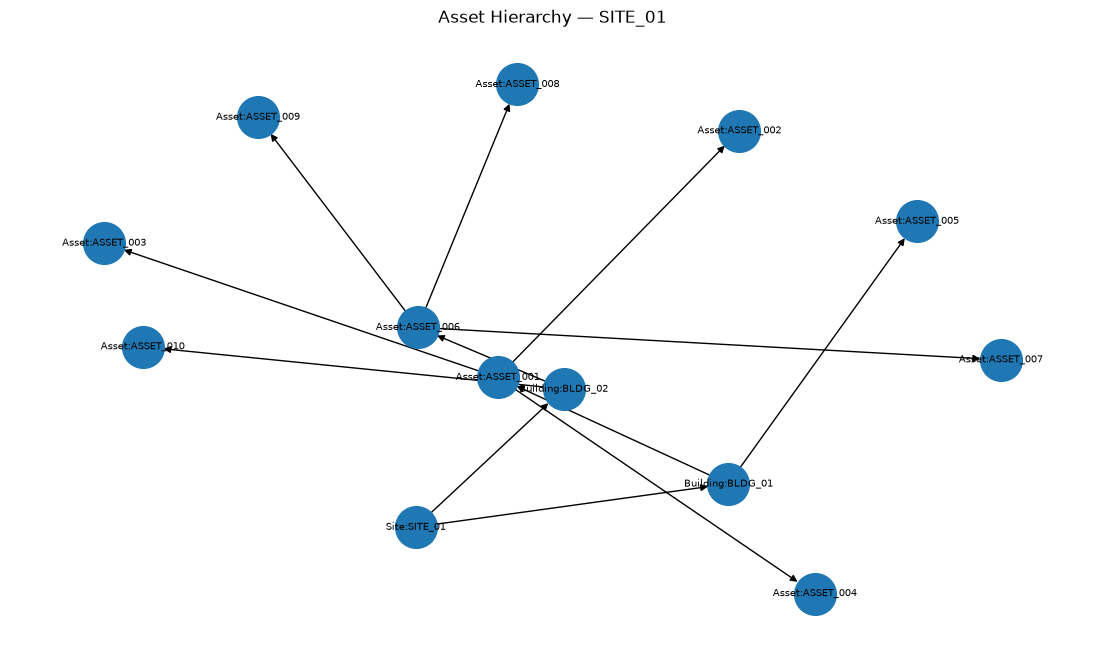

In [28]:
# Build a hierarchy graph using site, building and parent relationships

H = nx.DiGraph()

for _, row in metadata.iterrows():

    site_node = f"Site:{row['site_id']}"
    building_node = (
        f"Building:{row['building_id']}"
    )
    asset_node = f"Asset:{row['asset_id']}"

    H.add_node(site_node, level="site")
    H.add_node(building_node, level="building")
    H.add_node(
        asset_node,
        level="asset",
        asset_type=row["asset_type"]
    )

    H.add_edge(site_node, building_node)

    if pd.isna(row["parent_asset_id"]):
        H.add_edge(building_node, asset_node)
    else:
        parent_node = f"Asset:{row['parent_asset_id']}"
        H.add_edge(parent_node, asset_node)

# Display one site/building hierarchy
selected_site = metadata["site_id"].iloc[0]

hierarchy_nodes = [
    node for node in H.nodes
    if (
        node == f"Site:{selected_site}"
        or node.startswith("Building:")
        or node.startswith("Asset:")
    )
]

# Limit to the selected site's reachable hierarchy
root = f"Site:{selected_site}"

if root in H:
    reachable = nx.descendants(H, root) | {root}
else:
    reachable = set()

plot_nodes = [
    node for node in H.nodes
    if node in reachable
]

H_plot = H.subgraph(plot_nodes).copy()

plt.figure(figsize=(14, 8))

pos = nx.spring_layout(
    H_plot,
    seed=SEED,
    k=1.2
)

nx.draw_networkx(
    H_plot,
    pos,
    with_labels=True,
    node_size=900,
    font_size=7,
    arrows=True
)

plt.title(
    f"Asset Hierarchy — {selected_site}"
)
plt.axis("off")

# Save the same hierarchy graph for the dashboard
CONNECTIVITY_DIR = OUTPUTS_DIR / "connectivity"
CONNECTIVITY_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    CONNECTIVITY_DIR / "asset_hierarchy.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()


### 09.2 Connectivity Network Visualization

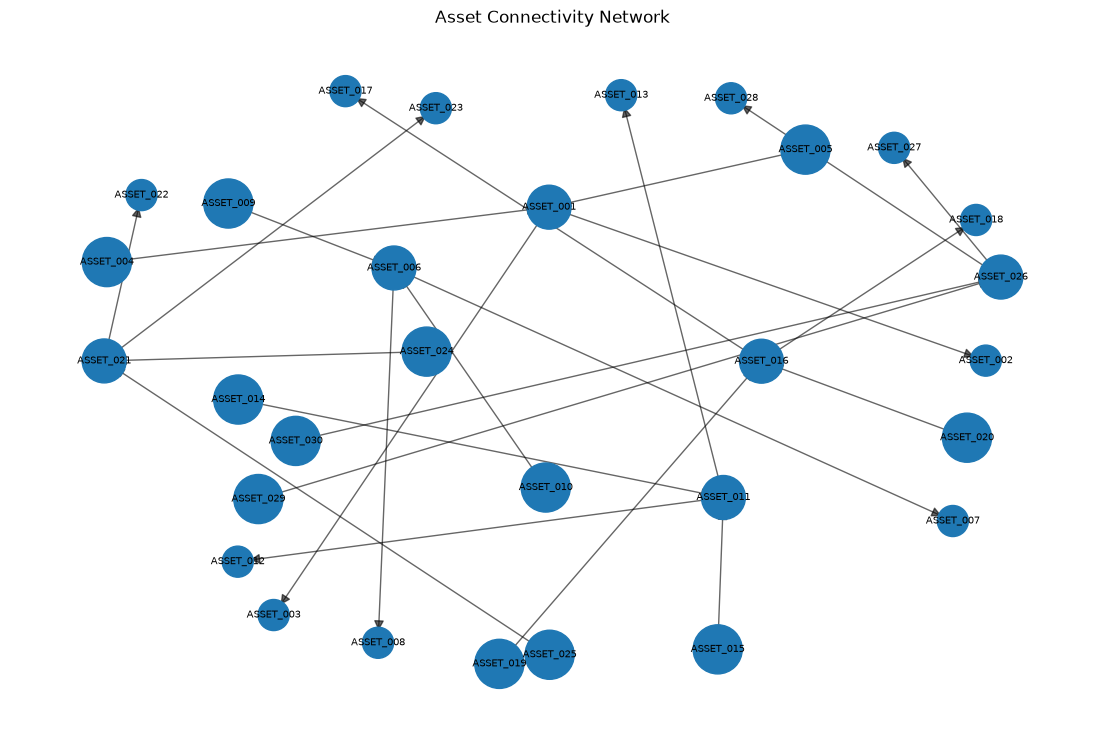

In [29]:
# Visualize the operational connectivity graph

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(
    G,
    seed=SEED,
    k=1.4
)

node_sizes = [
    500 + 250 * downstream_counts.get(node, 0)
    for node in G.nodes
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    alpha=0.6,
    arrowsize=15
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=7
)

plt.title("Asset Connectivity Network")
plt.axis("off")

# Save the same connectivity graph for the dashboard
CONNECTIVITY_DIR = OUTPUTS_DIR / "connectivity"
CONNECTIVITY_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    CONNECTIVITY_DIR / "asset_connectivity_network.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()


### 09.3 Failure Propagation Visualization

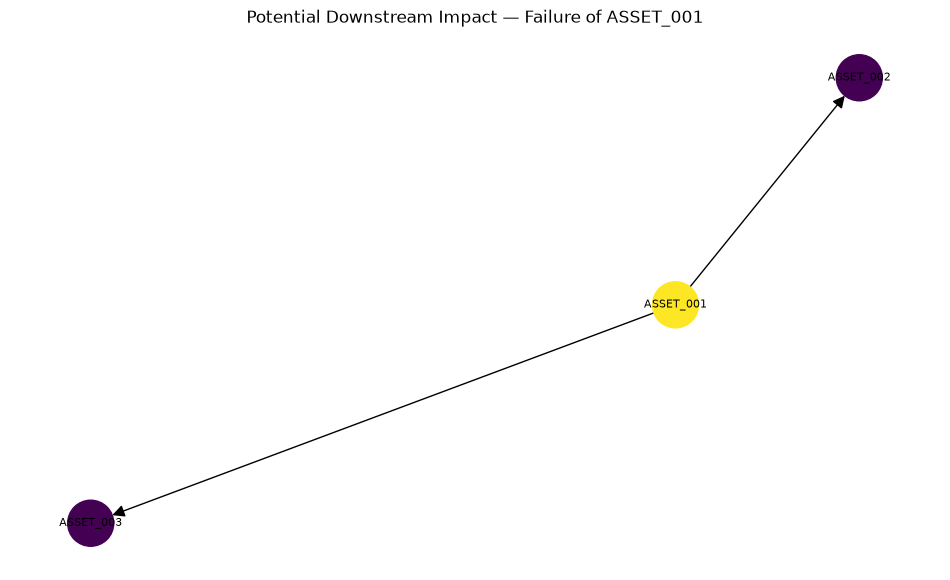

In [30]:
# Visualize downstream impact for the selected chiller

failure_asset = critical_chiller or list(G.nodes)[0]

downstream_nodes = set(
    get_downstream_assets(G, failure_asset)
)

impact_nodes = downstream_nodes | {failure_asset}

G_impact = G.subgraph(impact_nodes).copy()

plt.figure(figsize=(12, 7))

pos = nx.spring_layout(
    G_impact,
    seed=SEED,
    k=1.5
)

node_colors = [
    1 if node == failure_asset else 0
    for node in G_impact.nodes
]

nx.draw_networkx(
    G_impact,
    pos,
    with_labels=True,
    node_size=1100,
    node_color=node_colors,
    font_size=8,
    arrows=True,
    arrowsize=18
)

plt.title(
    f"Potential Downstream Impact — Failure of {failure_asset}"
)
plt.axis("off")

# Save the same failure-propagation graph for the dashboard
CONNECTIVITY_DIR = OUTPUTS_DIR / "connectivity"
CONNECTIVITY_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    CONNECTIVITY_DIR / "failure_propagation.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()


## 10. Connectivity Report

Create a compact report that answers the core business questions:

- Which assets are connected?
- Which assets have downstream dependencies?
- Which assets are isolated?
- Which assets have the largest downstream reach?

In [31]:
report = {
    "total_assets": G.number_of_nodes(),
    "total_connections": G.number_of_edges(),
    "isolated_assets": len(isolated_assets),
    "assets_with_downstream_dependencies": int(
        (criticality["downstream_count"] > 0).sum()
    ),
    "max_downstream_count": int(
        criticality["downstream_count"].max()
    ),
    "duplicate_connections": duplicate_connections,
    "invalid_parent_mappings": len(invalid_parents)
}

report_df = pd.DataFrame(
    {
        "Metric": list(report.keys()),
        "Value": list(report.values())
    }
)

display(report_df)

print("Top assets by downstream reach:")
display(
    criticality[
        [
            "asset_id",
            "asset_type",
            "downstream_count",
            "weighted_out_degree"
        ]
    ]
    .sort_values(
        "downstream_count",
        ascending=False
    )
    .head(10)
)

,Metric,Value
0,total_assets,30
1,total_connections,24
2,isolated_assets,0
3,assets_with_downstream_dependencies,18
4,max_downstream_count,3
5,duplicate_connections,0
6,invalid_parent_mappings,0


Top assets by downstream reach:


,asset_id,asset_type,downstream_count,weighted_out_degree
4,ASSET_005,Energy Meter,3,0.88
3,ASSET_004,Pump,3,0.70
8,ASSET_009,Pump,3,0.88
13,ASSET_014,Pump,3,0.91
9,ASSET_010,Energy Meter,3,0.96
14,ASSET_015,Energy Meter,3,0.89
23,ASSET_024,Pump,3,0.88
24,ASSET_025,Energy Meter,3,0.85
28,ASSET_029,Pump,3,0.81
29,ASSET_030,Energy Meter,3,0.84


## 11. Business Recommendations

### High downstream influence
Prioritize monitoring and preventive maintenance for assets with many downstream dependencies.

### Chiller failure
A chiller with connected AHUs may create a potential cooling-service impact across those downstream assets. Check alternate cooling capacity and prioritize connected AHUs.

### Pump failure
For a pump supplying downstream equipment, inspect the fluid circulation path and monitor affected equipment.

### Isolated assets
Validate whether graph-isolated assets are genuinely independent or whether their connectivity records are incomplete.

### Data quality
Resolve duplicate or invalid relationships before using the graph for automated failure-propagation decisions.

> **Important:** Graph connectivity indicates potential dependency. Actual physical impact should be confirmed using engineering/operational knowledge.

In [32]:
# 12. Save Connectivity Artifacts for the Dashboard

CONNECTIVITY_DIR = OUTPUTS_DIR / "connectivity"
CONNECTIVITY_DIR.mkdir(parents=True, exist_ok=True)

# Save the source relationship data used to construct the graph.
connectivity.to_csv(
    CONNECTIVITY_DIR / "asset_connectivity.csv",
    index=False
)

# Save the hierarchy/context data.
metadata[
    [
        "asset_id",
        "site_id",
        "building_id",
        "asset_name",
        "asset_type",
        "parent_asset_id"
    ]
].to_csv(
    CONNECTIVITY_DIR / "asset_hierarchy.csv",
    index=False
)

# Save the notebook's summary tables.
report_df.to_csv(
    CONNECTIVITY_DIR / "connectivity_summary.csv",
    index=False
)

criticality.to_csv(
    CONNECTIVITY_DIR / "criticality.csv",
    index=False
)

pd.DataFrame(
    {
        "Metric": [
            "duplicate_connections",
            "self_connections",
            "invalid_source_assets",
            "invalid_target_assets",
            "invalid_parent_mappings",
            "self_parent_mappings",
            "graph_isolated_assets"
        ],
        "Value": [
            duplicate_connections,
            self_connections,
            missing_source,
            missing_target,
            len(invalid_parents),
            len(self_parents),
            len(isolated_assets)
        ]
    }
).to_csv(
    CONNECTIVITY_DIR / "data_quality.csv",
    index=False
)

print("Saved connectivity artifacts to:", CONNECTIVITY_DIR.resolve())

print("Dashboard graph artifacts:")
for graph_file in [
    "asset_hierarchy.png",
    "asset_connectivity_network.png",
    "failure_propagation.png",
]:
    print(" -", (CONNECTIVITY_DIR / graph_file).resolve())


Saved connectivity artifacts to: C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\connectivity
Dashboard graph artifacts:
 - C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\connectivity\asset_hierarchy.png
 - C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\connectivity\asset_connectivity_network.png
 - C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\connectivity\failure_propagation.png
